# CSCI 3352 Biological Networks, Prof. Clauset
Submit here: https://canvas.colorado.edu/courses/101449

# Problem Set 8 : Protein Interaction Networks

***

**Name**: Dominic Galgano

***

This assignment is due on Canvas by **11:55pm on Friday, March 22**. Your solutions to non-programming questions should be done in Markdown directly below the associated question. Your solutions to computational questions should include any specified Python code and results as well as written commentary on your conclusions.  Remember that you are encouraged to discuss the problems with your classmates, but **you must write all code and solutions on your own** (see syllabus for detailed guidance). There are 70 points total, and 15 pts extra credit.

**NOTES**: 

- Unless a url is given for a data set, you will find the required data on the course Canvas.
- If you're not familiar with typesetting math directly in Markdown, you may do your work on paper first and then typeset it later. This [reference guide](https://math.meta.stackexchange.com/questions/5020/mathjax-basic-tutorial-and-quick-reference) provides helpful guidance for writing math in Markdown. 
- It is **unhelpful** to make your reader interpret numerical output from your code.  If a question asks you to compute some value from the data you should show your code output **AND** write a summary of the results in Markdown directly below your code.

***
* networkx [Documentation](https://networkx.github.io/documentation/stable/) and [Tutorial](https://networkx.github.io/documentation/stable/tutorial.html)
* igraph [Documentation](https://igraph.org/python/versions/latest/install.html) and [Tutorial](https://igraph.org/python/tutorial/0.9.8/tutorial.html)

In [31]:
import networkx as nx
import numpy as np
import matplotlib
import matplotlib.pylab as plt

%matplotlib inline

In [32]:
def drawGz(G,z):
    # DO NOT MODIFY THIS FUNCTION
    # This function draws G with node labels from partition z
    #
    # input  : G is a networkx graph
    #        : z is a dictionary of group labels for G's nodes
    # output : none
    # 
    # WARNING: function is optimistic: assumes inputs are properly formatted

    colors = ['#d61111','#11c6d6','#d67711','#11d646','#1b11d6','#d611cc'] # map node labels to colors (for the visualization)

    node_colors = []
    for i in G.nodes():
        node_colors.append(colors[int(z[i])])
    nsize  = 600
    flabel = True

    if G.order() > 50:
        nsize  = 100
        flabel = False
        
    nx.draw_networkx(G,with_labels=flabel,node_size=nsize,width=2,node_color=node_colors) # draw it pretty
    limits=plt.axis('off')                                      # turn off axes
    plt.show() 

    return

***
## Problem 1 : Warm ups (20 pts total)

Three warm up exercises, with some new network statistics.

### Problem 1-A (5 pts) : Participation coefficient

The *participation coefficient* $P_i$ is a node-level measure for how much of a node's connectivity is directed inside or outside the module it sits in. This measure was introduced in Guimera et al. "[Functional cartography of complex
metabolic networks.](https://www.nature.com/articles/nature03288)" *Nature* **433** (2005). The mathematical form of $P_i$ was chosen to that $P_i\approx1$ if $i$'s connections are distributed evenly among the modules, and $P_i\approx0$ if $i$'s connections are entirely to nodes in one module (typically its own). You can think of a node's "participation" as measuring how much it participates in *other* modules; hence, a low participation coefficient means *not* connecting to many other modules. It's defined as

$P_i = 1 - \sum_{s=1}^c \left(g_{i,s}\left/k_i\right. \right)^2$

where $s$ runs over the list of groups, $k_i$ is the degree of node $i$, and the variable $g_{i,s}$ counts the number of connections that node $i$ has to any nodes in group $s$, like this:

$g_{i,s} = \sum_j A_{ij}\delta_{s,z_j}$

* For the example graph below (same one as in PS6), calculate by hand the participation coefficients for nodes $0$, $3$, and $5$. Show your work.

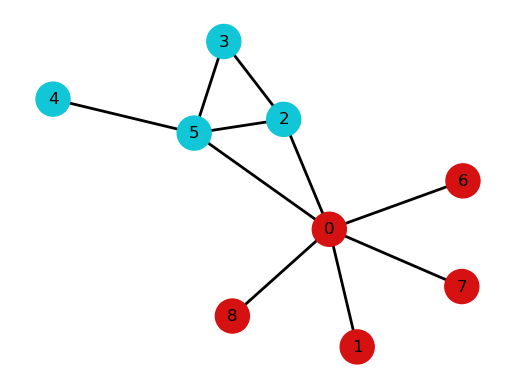

In [33]:
G = nx.Graph([(0,1),(0,2),(0,5),(0,6),(0,7),(0,8),(2,3),(2,5),(4,5),(3,5)]) # a simple graph G
z = {0: 0, 1: 0, 2: 1, 3: 1, 4: 1, 5: 1, 6: 0, 7: 0, 8: 0}                  # a partition of G into 2 groups

drawGz(G,z)

For 0: 

$P_0 = 1 - \sum_{s=1}^2 \left(g_{0,s}\left/k_0\right. \right)^2$

$P_0 = 1 - \left(g_{0,red}\left/k_0\right. \right)^2 + \left(g_{0,blue}\left/k_0\right. \right)^2$

$P_0 = 1 - (\frac{4}{6})^2 + (\frac{2}{6})^2 = 1 - (\frac{5}{9})$

$P_0 = \frac{4}{9} \approx 0.444$

For 3: 

$P_3 = 1 - \sum_{s=1}^2 \left(g_{3,s}\left/k_3\right. \right)^2$

$P_3 = 1 - \left(g_{3,red}\left/k_3\right. \right)^2 + \left(g_{3,blue}\left/k_3\right. \right)^2$

$P_3 = 1 - (\frac{0}{2})^2 + (\frac{2}{2})^2 = 1 - (\frac{4}{4})$

$P_3 = 0$

For 5: 

$P_5 = 1 - \sum_{s=1}^2 \left(g_{5,s}\left/k_5\right. \right)^2$

$P_5 = 1 - \left(g_{5,red}\left/k_5\right. \right)^2 + \left(g_{5,blue}\left/k_5\right. \right)^2$

$P_5 = 1 - (\frac{1}{4})^2 + (\frac{3}{4})^2 = 1 - (\frac{5}{8})$

$P_5 = \frac{3}{8} = 0.375$


### Problem 1-B (5 pts) : Degree $z$-score

Depending on whether a node is higher or lower degree, it may "participate" more or less in the modular structure of the network:

1. A _high-degree_ node with a _low participation_ score is one firmly anchored within its own module, because most of its many connects are to other nodes in its module.
* A _high-degree_ node with a _high participation_ score is one that connects to many other modules.
* Similarly, a _low-degree_ node with a _high participation_ score is likely a kind of "bridge" between a small number of different modules.
* And, a _low-degree_ node with a _low participation_ score is likely a peripheral node within its module.

Because it varies by network what the natural "scale" is by which to say a node is high or low degree, we'll use a simple $z$-score to make the distinction. That is, if a node's degree is above average, we'll call it high degree, and we'll say how high degree it is based on how far out in the tail it is. This degree $z$-score is defined thus:

$z_i = \Big(k_i - \langle k \rangle\Big)\left/\sigma_k\right.$

where $k_i$ is the degree of node $i$, $\langle k \rangle$ is the mean degree in the network, and $\sigma_k$ is the standard deviation of the degrees in the network. $z_i$ thus measures how many standards deviations node $i$'s degree is above or below the mean.

* For the example graph above, calculate by hand the degree $z$-scores for nodes $0$, $3$, and $5$. Show your work.

Hint: Be sure to use the [corrected standard deviation](https://en.wikipedia.org/wiki/Standard_deviation#Corrected_sample_standard_deviation) rather than the uncorrected one.

First find $<k>$:

$<k> = (k_0 + ... + k_8)\space/\space 9 = (6 + 1 + 3 + 2 + 1 + 4 + 1 + 1 + 1)\space/\space 9 \approx 2.222$

Next find $\sigma_k$:

Assuming $\sigma_k = \sqrt{\frac{1}{N} \sum_{i=0}^{N - 1} (k_i + <k>)^2}$ then 

$\sigma_k = \sqrt{\frac{1}{9}((6 + 2.222)^2 + (4 + 2.222)^2) + (3 + 2.222)^2 + (2 + 2.222)^2 + 5(1 + 2.222)^2)}$

$\sigma_k = 4.753$

Finally we can calculate:

$z_0 = (6 - 2.222) / 4.753 = 0.7949$

$z_3 = (2 - 2.222) / 4.753 = -0.0467$

$z_5 = (4 - 2.222) / 4.753 = 0.3741$


In [34]:
import math

#Simple calulation of standard dev 
k = 2.222
o_k = math.sqrt((((6 + k)**2) + ((4 + k)**2) + ((3 + k)**2) + ((2 + k)**2) + (5 * ((1 + k)**2))) / 9)
print(o_k)

#Simple calculator for z vals
z0 = (6 - k) / o_k
z3 = (2 - k) / o_k
z5 = (4 - k) / o_k
print(f"Z0 = {z0}   Z3 = {z3}   Z5 = {z5}")

4.752958797773585
Z0 = 0.7948732906689024   Z3 = -0.046707747625329886   Z5 = 0.37408277152178626


### Problem 1-C (10 pts) : Warm up, by code

* Now write two functions:
  * `calculate_Participation()`, which takes as input a graph $G$, a partition $z$, and a node choice $i$, and returns the participation coefficient $P_i$, and
  * `calculate_DegreezScore()`, which takes as input a graph $G$, and a node choice $i$, and returns the degree $z$-score $z_i$.
* Then apply those functions to verify that you did the by-hand calculations in `Problem 1-A` and `1-B` correctly.

Hint: See the Hint in `Problem 1-B`. Note that the default in `numpy` is the uncorrected estimator.

In [35]:
def calculate_Participation(G,z,i):
    # This function calculates the participation coefficient of node i, given graph G and partition z
    #
    # input  : G, anetworkx simple graph with n nodes
    #        : z is a dictionary of group labels for G's nodes
    #        : i, a node in G
    # output : P_i, the participation coefficient
    # 
    # WARNING: function is optimistic: assumes inputs are properly formatted
    
    ### YOUR CODE (my code: 9 lines, plus return)
    
    #First determine number of groups
    c = len(set(z.values()))
    #Next determine node's degree
    k_i = G.degree(i)
    #Initialize return value
    P_i = 0
    
    for group in range(c):
        g_is = 0
        #If neighbor is in the current group increment
        for node, neighbor in G.edges(i):
            if z[neighbor] == group:
                g_is = g_is + 1
        
        P_i = P_i + ((g_is / k_i)**2)
    
    return 1 - P_i


In [36]:
def calculate_DegreezScore(G,i):
    # This function calculates the degree z-score of node i, given graph G
    #
    # input  : G, anetworkx simple graph with n nodes
    #        : i, a node in G
    # output : z_i, the degree z-score
    # 
    # WARNING: function is optimistic: assumes inputs are properly formatted
    
    ### YOUR CODE (my code: 5 lines, plus return)
    import math
    
    k_i = G.degree(i)
    k_m = 2 * G.number_of_edges() / G.number_of_nodes()
    o_k = 0
    
    #Calculate corrected std deviation
    for node, degree in G.degree():
        o_k = o_k + ((degree + k_m)**2)
    
    o_k = math.sqrt(o_k / len(G.degree))
    
    #Calculate z score
    z_i = (k_i - k_m) / o_k
    
    return z_i


In [37]:
### DO NOT MODIFY THIS BLOCK
Pi = calculate_Participation(G,z,0)
zi = calculate_DegreezScore(G,0)
print(f'P_0 = {Pi}\nz_0 = {zi}\n')

Pi = calculate_Participation(G,z,3)
zi = calculate_DegreezScore(G,3)
print(f'P_3 = {Pi}\nz_3 = {zi}\n')

Pi = calculate_Participation(G,z,5)
zi = calculate_DegreezScore(G,5)
print(f'P_5 = {Pi}\nz_5 = {zi}\n')

P_0 = 0.4444444444444444
z_0 = 0.7947917897607135

P_3 = 0.0
z_3 = -0.046752458221218464

P_5 = 0.375
z_5 = 0.37401966576974754



***
## Problem 2 : Structural roles in a PPIN (50 pts total)

In this problem, you will
- use the two functions from `Problem 1` to characterize the structural roles that different proteins play in a relatively recent (and thus relatively accurate) estimate of the human protein-protein interaction network (PPIN)
- explore the biological functions of some particular nodes using the [Gene Ontology (GO)](http://geneontology.org) database.

Because this PPIN is pretty large ($n=12,\!250$ nodes), you won't be running your DC-SBM community detection code on it to obtain a partition $z$. That would take a rather long time. Instead, you'll use a partition produced by the DC-SBM implementation in [graph-tool](https://graph-tool.skewed.de).

The PPIN dataset is derived from a _H. sapiens_ network produced by the [Yu lab](http://hint.yulab.org), which combines interaction data from multiple sources, including high-throughput experiments.

### Problem 2-A (15 pts) : Import the network and partition

To begin, import the provided PPIN file `HINT_network.gml` as a `networkx` simple graph $G$, and extract as $z$ the partition included in the GML file.

To do this, you'll need to figure out how to use `networkx` to read in the node attributes included in the GML. Each `node` object has two additional variables associated with it:
* `mb` is the group label or community assigned to it by the DC-SBM (which returned $c=104$ groups), and 
* `ref_id` is an integer index that you'll use to look up the corresponding `gene.name` string of that node in `Problem 2-C`.

For example:

`   node [
      id 1
      mb 1
      ref_id "3727"
   ]`

In [77]:
fname1 = 'HINT_network.gml'
print(f'reading the network file : {fname1}\n')
G = nx.read_gml('./' + fname1, label='id')
print(f'number of nodes = {G.order()}')
print(f'number of edges = {G.size()}')

# here are two clever tricks to see what node attributes G has, which I used to
# verify that the nx.read_gml() function imported the node attributes properly
#set(np.array([list(G.node[n].keys()) for n in G.nodes()]).flatten())
#set([k for n in G.nodes for k in G.nodes[n].keys()])

# YOUR CODE
z = {node: data['mb'] for node, data in G.nodes(data=True)}
#print(z)
rfid = {node: data['ref_id'] for node, data in G.nodes(data=True)}
#print(rfid)

#nodeattr = set(np.array([list(G.nodes[n].keys()) for n in G.nodes()]).flatten())
#nodeattr = set([k for n in G.nodes for k in G.nodes[n].values()])
#print(nodeattr)

reading the network file : HINT_network.gml

number of nodes = 12250
number of edges = 58445


### Problem 2-B (15 pts) : Compute and plot $(P_i,z_i)$ pairs

* First, compute and store a pair $(P_i,z_i)$ for each node $i$ in the PPIN.
* Then, make a scatter plot of these values with the degree $z$-scores on the $y$-axis.
* Discuss what you see. Be sure to highlight any unusual patterns, describe where "most" of the data sits, and articulate what this plot tells you about the organization of the PPIN.

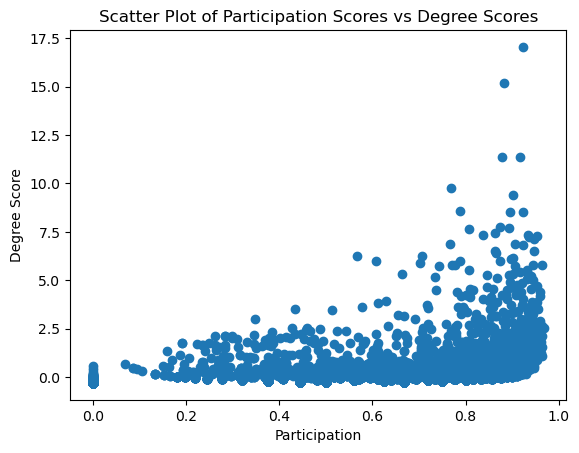

In [79]:
# YOUR CODE
def calculate_Part_opt(G,z,i,c):
    # This function calculates the participation coefficient of node i, given graph G and partition z
    #
    # input  : G, anetworkx simple graph with n nodes
    #        : z is a dictionary of group labels for G's nodes
    #        : i, a node in G
    #        : c, number of groups
    # output : P_i, the participation coefficient
    # 
    # WARNING: function is optimistic: assumes inputs are properly formatted
    
    ### YOUR CODE (my code: 9 lines, plus return)
    
    #Next determine node's degree
    k_i = G.degree(i)
    #Initialize return value
    P_i = 0
    
    for group in range(c):
        g_is = 0
        #If neighbor is in the current group increment
        for node, neighbor in G.edges(i):
            if z[neighbor] == group:
                g_is = g_is + 1
        
        P_i = P_i + ((g_is / k_i)**2)
    
    return 1 - P_i

def calculate_DegreezScore_opt(G,i,k_m,o_k):
    # This function calculates the degree z-score of node i, given graph G
    #
    # input  : G, anetworkx simple graph with n nodes
    #        : i, a node in G
    #        : k_m, the mean degree of the net
    #        : o_k, the corrected std dev of the net
    # output : z_i, the degree z-score
    # 
    # WARNING: function is optimistic: assumes inputs are properly formatted
    
    k_i = G.degree(i)
    z_i = (k_i - k_m) / o_k
    
    return z_i

#Initiate necessary variables
P_i = 0
z_i = 0
PPIN = {}

#Determine number of groups one time
c = len(set(z.values()))
#Determine mean degree one time
k_m = 2 * G.number_of_edges() / G.number_of_nodes()
#Determine correct std dev once
o_k = 0
for node, degree in G.degree():
        o_k = o_k + ((degree + k_m)**2)
    
o_k = math.sqrt(o_k / len(G.degree))

#Determine the P_i and z_i for each node in the network
for i in G.nodes():
    P_i = round(calculate_Part_opt(G,z,i,c), 4)
    z_i = round(calculate_DegreezScore_opt(G,i,k_m,o_k), 4)
    PPIN[i] = (P_i, z_i)
    
#print(PPIN)

#Make a scatter plot
x = [pair[0] for pair in PPIN.values()]
y = [pair[1] for pair in PPIN.values()]

plt.scatter(x, y)
plt.xlabel('Participation')
plt.ylabel('Degree Score')
plt.title('Scatter Plot of Participation Scores vs Degree Scores')
plt.show()

Based on this scatter plot, it appears the greater level of participation indicates a node will likely have a higher degree score. However, it also appears the partcipation of a node does not seem to directly correlate to the degree score of a node as pretty consistently at all participation levels, a significant protion of nodes have a low degree score. Additionally it is worth noting there are many nodes with zero participation in other groups outside their own, and these nodes all have extremely low degree scores. It may be deduced from this that there are many nodes/protiens who only communicate with one fellow node/protien or are complete disconnected and never communicate with any other nodes. Overall most of the data sits between 0 and 3 degree score and between 0.2 and 0.9 participation levels.

### Problem 2-C (20 pts) : Dig into the details

* Based on the scatter plot in `Problem 2-B`, pick out $10$ nodes that have unusual combinations of participation and degree $z$-scores. Try to choose a variety, if you can. In the markdown box below, make a markdown table with columns for
  * `G.i` (the node's index in $G$),
  * the corresponding `ref_id` value,
  * the `gene.name` associated with that `ref_id` in the provided `all_hint_nodes_names` file, 
  * $P_i$,
  * $z_i$,
  * `GO terms`
  * `GO URL`
* Then, use the [Gene Ontology](http://geneontology.org) database to look up the GO class(es) associated with each, which tell us about which biological functions a protein is involved in. (When you do this, you'll want to select the "Genes and gene products" list of results, or click "Gene products" on the initial search.) 
* List some or all of these in the `GO terms` column (you may omit "protein binding", which is generic), and put the URL for the search results ([like this](http://amigo.geneontology.org/amigo/gene_product/UniProtKB:A2RU48)) in the `GO URL` column.
* Finally, based on your small (and not statistically representative sample) discuss
  1. whether there appears to be any correlation between biological function and either participation or degree $z$-score, and 
  * how you could test this hypothesis computationally. <br/>

*(5 pts extra credit)* For doing $15$ nodes instead of $10$.

Hint: When you look up the GO terms, make sure you select the version of the gene associated with *Homo sapiens*.

In [93]:
# YOUR CODE
max_ind_p_i = 0
min_ind_p_i = 0
max_ind_z_i = 0
min_ind_z_i = 0
for index, pair in PPIN.items():
    #determine max pi
    if pair[0] > x[max_ind_p_i]:
        max_ind_p_i = index
    #determine min pi
    if pair[0] < x[min_ind_p_i]:
        min_ind_p_i = index
    #determine max zi
    if pair[1] > y[max_ind_z_i]:
        max_ind_z_i = index
    #determine min pi
    if pair[1] < y[min_ind_z_i]:
        min_ind_z_i = index

print("P max", max(x), "P min", min(x))
print("Z max", max(y), "Z min", min(y))
print(max_ind_p_i, rfid[max_ind_p_i], PPIN[max_ind_p_i])
print(min_ind_p_i, rfid[min_ind_p_i], PPIN[min_ind_p_i])
print(max_ind_z_i, rfid[max_ind_z_i], PPIN[max_ind_z_i])
print(min_ind_z_i, rfid[min_ind_z_i], PPIN[min_ind_z_i])

high_Z = []
odd_pi = []
for index, pair in PPIN.items():
    if pair[1] > 10:
        high_Z.append(index)
    if pair[0] > 0.5 and pair[0] < 0.8 and pair[1] > 5.0 and pair[1] < 7.5:
        odd_pi.append(index)
        
import random
        
for node in high_Z:
    print(node, rfid[node], PPIN[node])
for node in odd_pi:
    print(node, rfid[node], PPIN[node])


P max 0.9675 P min 0.0
Z max 17.0579 Z min -0.3124
1326 3128 (0.9675, 2.5034)
0 0 (0.0, -0.3124)
336 1538 (0.9225, 17.0579)
0 0 (0.0, -0.3124)
140 11290 (0.877, 11.3531)
147 3859 (0.9168, 11.3897)
255 3488 (0.8829, 15.1929)
336 1538 (0.9225, 17.0579)
87 10834 (0.7426, 5.7215)
252 1439 (0.6081, 6.0141)
294 11919 (0.7712, 5.7581)
346 10799 (0.7671, 6.8917)
432 10341 (0.7058, 6.2335)
760 1959 (0.5674, 6.27)
815 2368 (0.7333, 5.173)
1425 1211 (0.7027, 5.8678)
1487 1346 (0.7887, 5.9775)
1639 11693 (0.6624, 5.3192)
2225 10835 (0.7764, 5.7581)


| G.i  | ref_id | gene.name | Pi     | zi      | GO terms                             | GO URL |
| ---- | ------ | --------- | ------ | ------- | ------------------------------------ | ------ |
| 1326 | 3128   |  KPNA2    | 0.9675 | 2.50340 | Nuclear localiztion sequence binding |   [link](https://amigo.geneontology.org/amigo/gene_product/UniProtKB:F7D853) |
| 336  | 1538   | HSP90AB1  | 0.9225 | 17.0579 | Cellular repose to hear; perinuclear region or cytoplasm | [link](https://amigo.geneontology.org/amigo/gene_product/UniProtKB:A0A6I8P1P4) |
| 0    | 0      |RPS10-NUDT3| 0.0    | -0.3124 | Structural constituent of ribosome; cytosolic small ribosomal subunit | [link](https://amigo.geneontology.org/amigo/gene_product/UniProtKB:P48854)|
| 140  | 11290  | KRT40     | 0.877  | 11.3531 | intermediate filament organization; epithelial cell differentiation; cytoskeleton | [link](https://amigo.geneontology.org/amigo/gene_product/UniProtKB:A0A337SKZ4) |
| 147  | 3859   | GOLGA2    | 0.9168 | 11.3897 | cis-Golgi network; Golgi cisterna membrane | [link](https://amigo.geneontology.org/amigo/gene_product/UniProtKB:A0A6I8P9W3) |
| 255  | 3488   | GRB2      | 0.8829 | 15.1929 | nucleoplasm; plasma membrane; regulation of MAPK cascade | [link](https://amigo.geneontology.org/amigo/gene_product/UniProtKB:F7BQS3) |
| 346  | 10799  | TERF1     | 0.7712 | 6.89170 | telomere maintenance via telomerase; DNA binding, bending; nuclear telomere cap complex | [link](https://amigo.geneontology.org/amigo/gene_product/UniProtKB:F7EB98) |
| 252  | 1439   | FYN       | 0.6081 | 6.01410 | T cell receptor signaling pathway; protein phosphorylation; innate immune response | [link](https://amigo.geneontology.org/amigo/gene_product/UniProtKB:A0A5F5PHH1) |
| 760  | 1959   | NCK1      | 0.5674 | 6.27000 | signal transduction; negative regulation of endoplasmic reticulum stress-induced eIF2 alpha phosphorylation | [link](https://amigo.geneontology.org/amigo/gene_product/UniProtKB:F7E0A3) |
| 432  | 10341  | CREB3     | 0.7058 | 6.23350 | regulation of transcription by RNA polymerase II; DNA-binding transcription factor activity| [link](https://amigo.geneontology.org/amigo/gene_product/UniProtKB:A0A6I8NYH0) |
| 815  | 2368   | PIK3R1    | 0.7333 | 5.17300 | phosphatidylinositol 3-kinase complex; insulin receptor signaling pathway | [link](https://amigo.geneontology.org/amigo/gene_product/UniProtKB:F7BZL6) |
| 1425 | 1211   | ABL1      | 0.7027 | 5.86780 | epidermal growth factor receptor signaling pathway; protein tyrosine kinase activity | [link](https://amigo.geneontology.org/amigo/gene_product/UniProtKB:A0A1D5R032) |
| 1487 | 1346   | TK1       | 0.7887 | 5.97750 | thymidine kinase activity | [link](https://amigo.geneontology.org/amigo/gene_product/UniProtKB:F7DNI7) |
| 1639 | 11693  | ALDOC     | 0.6624 | 5.31920 | cytosol; fructose-bisphosphate aldolase activity; glycolytic process | [link](https://amigo.geneontology.org/amigo/gene_product/UniProtKB:A0A287B8Z2) |
| 2225 | 10835  | KRTAP10-9 | 0.7764 | 5.75810 | protien binding | [link](https://amigo.geneontology.org/amigo/gene_product/UniProtKB:P60411) |



* Finally, based on your small (and not statistically representative sample) discuss
  1. whether there appears to be any correlation between biological function and either participation or degree $z$-score, and 
  * how you could test this hypothesis computationally. <br/>
  
Although I haven't taken a biology class since freshman year of highschool, in regards to biological function there appear to be some similarities. From the list of not statistically respresentative data I have collected, many protiens with irregular participation and degree scores either signal other to protiens or regulate DNA in one way or another(This may be the general task of every protien for all I know). My list mostly samples protiens with irregularly high p and z scores, however the one which is a sample of the lowest possible p and z values, RPS10-NUDT3, says it contributes to the structural integrity of the rather than act in any sort of communicational/regulational capacity. To test this computationally, I would first calculate the praticipation and degree scores of all the protiens in the network as we have done. Next I would sort these protiens based on their general biological functions(i.e. group 1 = signalling, group 2 = regulating, group 3 = structural itegrity).  I would then calculate an average praticipation and $z$-score for each of these groups and compare them to each other to see if there was a significant difference in these scores between the groups of different biological functions. Additionally, I may check to see how great the variance of praticipation and  $z$-scores was from the average to ensure the average scores represented the group properly. Finally, I would plot the groups with distiguishing colors on a scatter plot of $z$-score vs participation as we did above, to see visually if
protiens with similar biological functions landed in similar areas.


***
***

## Problem 3 : Reading the literature (*10 pts extra credit*)

Choose a paper from the [Supplemental Reading list on the external course webpage](https://aaronclauset.github.io/courses/3352/). Read the paper (the whole paper, not just the abstract). Think about what it says. Then, write 1-3 sentences for each of the following questions in a way that clearly summarizes the work, and its context.
* What paper did you choose?
* What was the research question?
* What was the approach the authors took to answer that question?
* What did they do well?
* What could they have done better?
* What extensions can you envision?


Do not copy any text from the paper itself; write your own summary, in your own words in Markdown in the corresponding box below. Be sure to answer each of the five questions. The amount of extra credit will depend on the accuracy and thoughtfulness of your answers.

Hint: This is a good way to generate some ideas for your class project (your proposal for that is due on **February 27th**. Also, even if you don't understand everything in the paper, that's okay. Do your best to summarize what you did understand.

* *What paper did you choose?*<br/>
Give the Authors, Title, Publication Venue, Year
<br/>

* *What was the research question?*<br/>
Your answer here
<br/>

* *What was the approach the authors took to answer that question?*<br/>
Your answer here
<br/>

* *What did they do well?*<br/>
Your answer here
<br/>

* *What could they have done better?*<br/>
Your answer here
<br/>

* *What extensions can you envision?*<br/>
Your answer here